In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [160]:
df = pd.read_csv('open-meteo-26.96N75.82E438m (1).csv', skiprows=3)

In [161]:
df.columns = [
    'time', 'weather_code', 'temp_mean', 'temp_max', 'temp_min',
    'precipitation_sum', 'rain_sum', 'wind_speed_max',
    'humidity_max', 'humidity_min', 'humidity_mean',
    'wind_speed_min', 'wind_speed_mean'
]
df.head()

,time,weather_code,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,wind_speed_max,humidity_max,humidity_min,humidity_mean,wind_speed_min,wind_speed_mean
0,2015-01-19,1,13.8,20.6,7.0,0.0,0.0,8.9,93,38,68,2.6,6.7
1,2015-01-20,3,14.1,20.7,8.3,0.0,0.0,18.3,94,39,68,7.8,11.9
2,2015-01-21,51,15.5,21.2,11.4,0.5,0.5,16.9,90,57,76,7.0,13.0
3,2015-01-22,61,15.2,19.0,12.6,8.0,8.0,14.1,96,72,87,2.2,6.9
4,2015-01-23,51,14.7,18.0,12.0,0.5,0.5,8.3,99,64,87,2.1,5.5


In [162]:
df.shape

(3972, 13)

In [163]:
df.isnull().sum()

time                 0
weather_code         0
temp_mean            0
temp_max             0
temp_min             0
precipitation_sum    0
rain_sum             0
wind_speed_max       0
humidity_max         0
humidity_min         0
humidity_mean        0
wind_speed_min       0
wind_speed_mean      0
dtype: int64

In [164]:
df['time'] = pd.to_datetime(df['time'])
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month

In [165]:
df = df.drop(columns=[
    'rain_sum', 'humidity_max', 'humidity_min',
    'wind_speed_max', 'wind_speed_min', 'weather_code'
])

In [166]:
df['heatwave'] = (df['temp_max'] >= 40).astype(int)
df['heatwave'].value_counts()

heatwave
0    3652
1     320
Name: count, dtype: int64

In [167]:
df['heatwave'].value_counts(normalize=True) * 100

heatwave
0    91.943605
1     8.056395
Name: proportion, dtype: float64

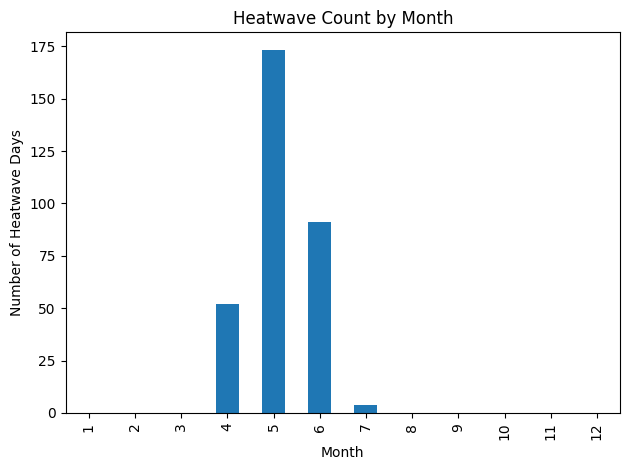

In [168]:
monthly_heatwave = df.groupby('month')['heatwave'].sum()

plt.figure()
monthly_heatwave.plot(kind='bar')
plt.title('Heatwave Count by Month')
plt.xlabel('Month')
plt.ylabel('Number of Heatwave Days')
plt.tight_layout()
plt.show()

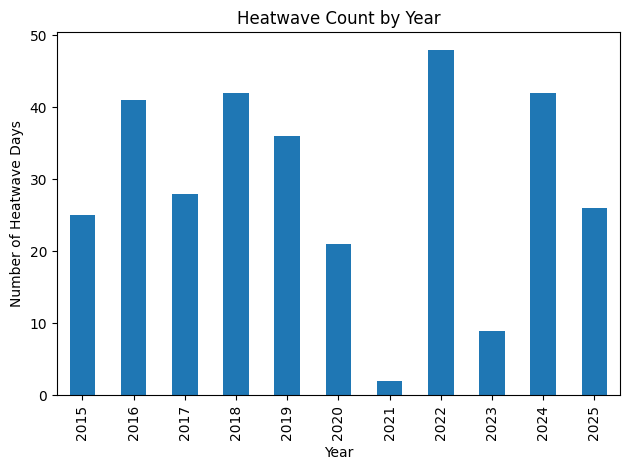

In [169]:
yearly_heatwave = df.groupby('year')['heatwave'].sum()

plt.figure()
yearly_heatwave.plot(kind='bar')
plt.title('Heatwave Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Heatwave Days')
plt.tight_layout()
plt.show()

In [170]:
df['temp_min_lag1']      = df['temp_min'].shift(1)
df['temp_mean_lag1']     = df['temp_mean'].shift(1)
df['humidity_lag1']      = df['humidity_mean'].shift(1)
df['precip_lag1']        = df['precipitation_sum'].shift(1)
df['wind_lag1']          = df['wind_speed_mean'].shift(1)

df['temp_mean_3d_avg']   = df['temp_mean'].shift(1).rolling(window=3).mean()

df = df.dropna()
df.head()

,time,temp_mean,temp_max,temp_min,precipitation_sum,humidity_mean,wind_speed_mean,year,month,heatwave,temp_min_lag1,temp_mean_lag1,humidity_lag1,precip_lag1,wind_lag1,temp_mean_3d_avg
3,2015-01-22,15.2,19.0,12.6,8.0,87,6.9,2015,1,0,11.4,15.5,76.0,0.5,13.0,14.466667
4,2015-01-23,14.7,18.0,12.0,0.5,87,5.5,2015,1,0,12.6,15.2,87.0,8.0,6.9,14.933333
5,2015-01-24,13.2,18.0,9.5,0.0,76,6.0,2015,1,0,12.0,14.7,87.0,0.5,5.5,15.133333
6,2015-01-25,13.7,18.9,7.7,0.0,72,6.5,2015,1,0,9.5,13.2,76.0,0.0,6.0,14.366667
7,2015-01-26,14.1,17.8,11.6,0.0,74,5.7,2015,1,0,7.7,13.7,72.0,0.0,6.5,13.866667


In [171]:
features = [
    'temp_min_lag1',
    'temp_mean_lag1',
    'humidity_lag1',
    'wind_lag1',
    'precip_lag1',
    'month',
    'temp_mean_3d_avg'
]

X = df[features]
y = df['heatwave']

In [172]:
train_df = df[df['year'] <= 2022]
test_df  = df[df['year'] >  2022]

X_train = train_df[features]
y_train = train_df['heatwave']
X_test  = test_df[features]
y_test  = test_df['heatwave']

print(f'Train: {len(X_train)} rows ({y_train.sum()} heatwave days)')
print(f'Test:  {len(X_test)} rows ({y_test.sum()} heatwave days)')

Train: 2901 rows (243 heatwave days)
Test:  1068 rows (77 heatwave days)


In [173]:
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [174]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[945  46]
 [  1  76]]

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       991
           1       0.62      0.99      0.76        77

    accuracy                           0.96      1068
   macro avg       0.81      0.97      0.87      1068
weighted avg       0.97      0.96      0.96      1068



In [175]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[978  13]
 [ 13  64]]

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       991
           1       0.83      0.83      0.83        77

    accuracy                           0.98      1068
   macro avg       0.91      0.91      0.91      1068
weighted avg       0.98      0.98      0.98      1068



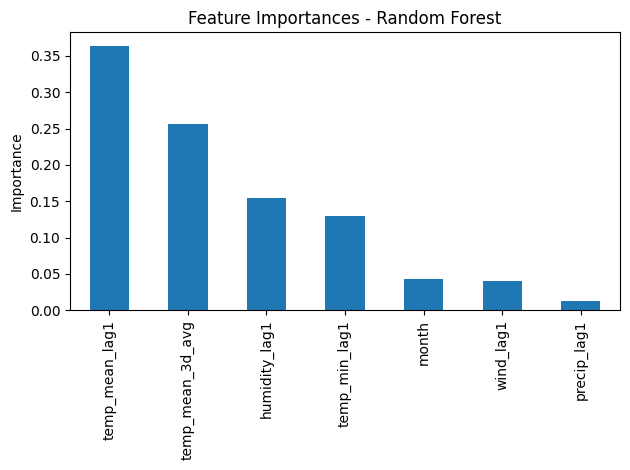

In [176]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure()
importances.plot(kind='bar')
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [179]:
df['temp_max_tomorrow'] = df['temp_max'].shift(-1)

df_reg = df.dropna(subset=['temp_max_tomorrow']).copy()

In [180]:
reg_features = [
    'temp_max',
    'temp_mean',
    'temp_min',
    'humidity_mean',
    'wind_speed_mean',
    'precipitation_sum',
    'month'
]

X_reg = df_reg[reg_features]
y_reg = df_reg['temp_max_tomorrow']

In [181]:
correlations = X_reg.corrwith(y_reg).sort_values(ascending=False)
print(correlations.round(3))

temp_max             0.971
temp_mean            0.947
temp_min             0.855
wind_speed_mean      0.351
precipitation_sum   -0.040
month               -0.048
humidity_mean       -0.473
dtype: float64


In [182]:
train_reg = df_reg[df_reg['year'] <= 2022]
test_reg  = df_reg[df_reg['year'] >  2022]

X_train_reg = train_reg[reg_features]
y_train_reg = train_reg['temp_max_tomorrow']
X_test_reg  = test_reg[reg_features]
y_test_reg  = test_reg['temp_max_tomorrow']

print(f'Train:{len(X_train_reg)} rows')
print(f'Test:{len(X_test_reg)} rows')

Train: 2901 rows
Test:  1067 rows


In [183]:
# baseline: always predict the training set mean — just to have a reference point
baseline_pred = np.full(len(y_test_reg), y_train_reg.mean())
baseline_mae  = mean_absolute_error(y_test_reg, baseline_pred)
print(f'Baseline MAE (always predict mean): {baseline_mae:.2f} °C')

Baseline MAE (always predict mean): 4.69 °C


In [184]:
scaler_reg   = StandardScaler()
X_train_sc_r = scaler_reg.fit_transform(X_train_reg)
X_test_sc_r  = scaler_reg.transform(X_test_reg)

lr_reg = LinearRegression()
lr_reg.fit(X_train_sc_r, y_train_reg)

y_pred_lr_reg = lr_reg.predict(X_test_sc_r)

print('Linear Regression:')
print(f'MAE:{mean_absolute_error(y_test_reg, y_pred_lr_reg):.2f} °C')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)):.2f} °C')
print(f'R²:{r2_score(y_test_reg, y_pred_lr_reg):.3f}')

Linear Regression:
  MAE:  1.01 °C
  RMSE: 1.39 °C
  R²:   0.947


In [187]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test_reg)

print('Random Forest Regressor:')
print(f'  MAE:  {mean_absolute_error(y_test_reg, y_pred_rf_reg):.2f} °C')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):.2f} °C')
print(f'  R²:   {r2_score(y_test_reg, y_pred_rf_reg):.3f}')

Random Forest Regressor:
  MAE:  1.06 °C
  RMSE: 1.46 °C
  R²:   0.941


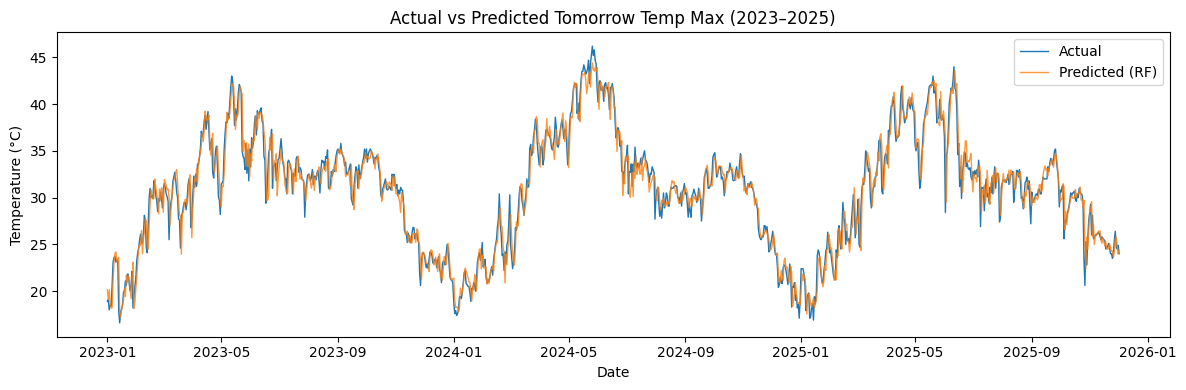

In [188]:
plt.figure(figsize=(12, 4))
plt.plot(test_reg['time'].values, y_test_reg.values, label='Actual', linewidth=1)
plt.plot(test_reg['time'].values, y_pred_rf_reg, label='Predicted (RF)', linewidth=1, alpha=0.8)
plt.title('Actual vs Predicted Tomorrow Temp Max (2023–2025)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

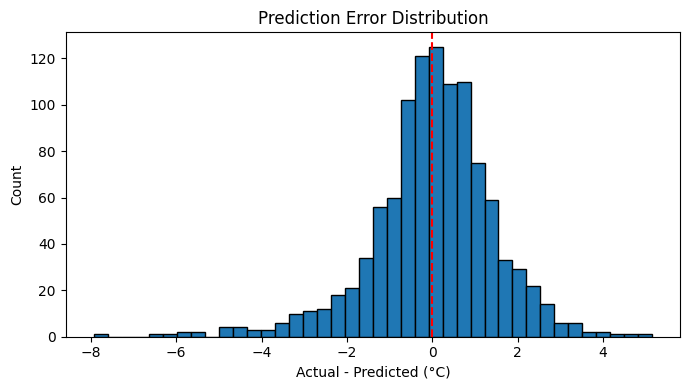

Mean error: 0.00 °C  (negative = model over-predicts)


In [189]:
errors = y_test_reg.values - y_pred_rf_reg

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=40, edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Actual - Predicted (°C)')
plt.ylabel('Count')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

print(f'Mean error: {errors.mean():.2f} °C  (negative = model over-predicts)')

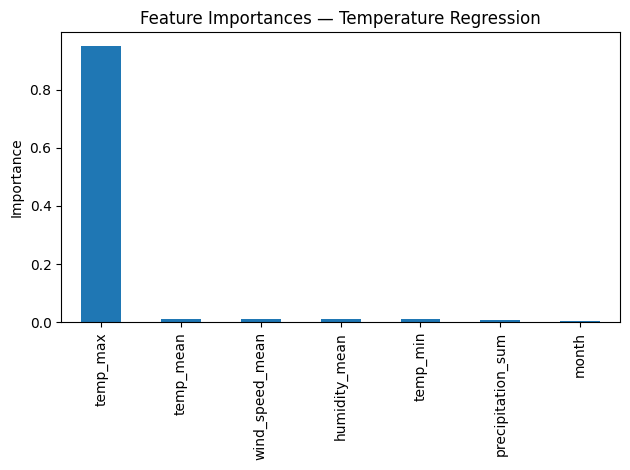

In [190]:
reg_importances = pd.Series(rf_reg.feature_importances_, index=reg_features).sort_values(ascending=False)

plt.figure()
reg_importances.plot(kind='bar')
plt.title('Feature Importances — Temperature Regression')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [191]:
import joblib
joblib.dump(rf_model, 'heatwave_model.pkl')
joblib.dump(rf_reg, 'temp_model.pkl')

['temp_model.pkl']